In [1]:
import tigre.algorithms as algs
import pickle
import numpy as np
import pathlib
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

In [2]:
base_dir = pathlib.Path("C:/CBCT_Scatter_Removal_Project/data/test/4105896/npy_data/")      

In [3]:
geo_file = base_dir / "20251212-202544_pt4105896_geo.pkl"
with open(geo_file,'rb') as gf:
    geo = pickle.load(gf)
geo.nVoxel = geo.nVoxel.astype('int')

In [4]:
recons = []
for file in base_dir.iterdir():
    if str(file)[-3:]=='npz':
        print(file)
        data = np.load(file)
        # projs = np.array([median_filter(p,size=(9,1)) for p in data["log_projs"].astype('float32')])
        projs = data["log_projs"].astype('float32')
        angles = data["angles"]
        recon = algs.fdk(projs.astype('float32'),geo,angles,filter='hann')
        recons.append(recon)

C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\20251210-024442_pt4105896_cnn_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\20251210-141034_pt4105896_cnn_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\20251210-204557_pt4105896_cnn_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\20251211-081647_pt4105896_cnn_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\20251211-194500_pt4105896_cnn_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\20251212-070941_pt4105896_cnn_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\20251212-134851_pt4105896_cnn_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\20251212-202544_pt4105896_cnn_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\pt4105896_dps_projs.npz
C:\CBCT_Scatter_Removal_Project\data\test\4105896\npy_data\pt4105896_fasks_projs.npz


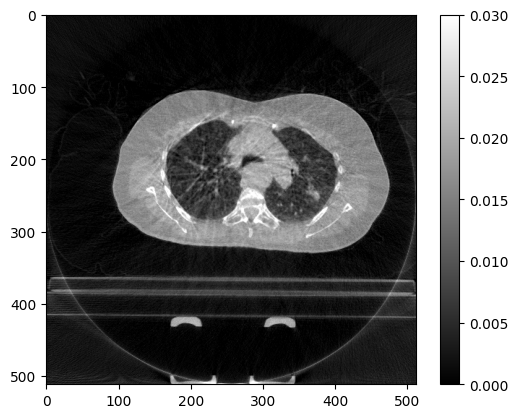

In [5]:
plt.imshow(recons[0][44].T,vmin=0,vmax=0.03,cmap='gray')
plt.colorbar()
plt.show()

In [6]:
i=0
for file in base_dir.iterdir():
    if str(file)[-3:]=='npz':
        np.save(str(file).replace("projs.npz","recon_hann.npy"),recons[i])
        i+=1


In [ ]:
from scipy.signal import convolve2d
import math

def estimate_noise(I):

  H, W = I.shape

  M = [[1, -2, 1],
       [-2, 4, -2],
       [1, -2, 1]]

  sigma = np.sum(np.sum(np.absolute(convolve2d(I, M))))
  sigma = sigma * math.sqrt(0.5 * math.pi) / (6 * (W-2) * (H-2))

  return sigma